In [1]:
import pandas as pd
df = pd.read_csv("Resume.csv")
df.head(5)
df.info()
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
Duplicate rows: 0


In [2]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.isnull().sum())

(2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [3]:
df = df[['Resume_str','Category']]
df.dropna(inplace=True)
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [4]:
print(df["Category"].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [5]:
import pandas as pd
df = pd.read_csv("Resume.csv")
df = df[['Resume_str', 'Category']]
df.dropna(inplace=True)
x = df["Resume_str"]
y = df["Category"]

SPLITING DATASET

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 1987
Testing samples: 497


CLEANING

In [7]:
import re
def clean(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t
x_train = x_train.apply(clean)
x_test = x_test.apply(clean)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.9)
x_train = tfidf.fit_transform(x_train)
x_test = tfidf.transform(x_test)


In [9]:
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(chi2, k=1500)
x_train = selector.fit_transform(x_train, y_train)
x_test = selector.transform(x_test)

APPLYING LOGISTICREGRESSION

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=3000,C=40,class_weight="balanced",random_state=42)
model.fit(x_train, y_train)
lr_train_acc = accuracy_score(y_train, model.predict(x_train))
lr_test_acc = accuracy_score(y_test, model.predict(x_test))
print(f"Logistic Regression (C=0.2) - Train: {lr_train_acc:.4f}  Test: {lr_test_acc:.4f}  Gap: {lr_train_acc-lr_test_acc:.4f}")


Logistic Regression (C=0.2) - Train: 0.9784  Test: 0.7887  Gap: 0.1896


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7887323943661971
                        precision    recall  f1-score   support

            ACCOUNTANT       0.74      0.83      0.78        24
              ADVOCATE       0.79      0.92      0.85        24
           AGRICULTURE       0.73      0.62      0.67        13
               APPAREL       0.64      0.47      0.55        19
                  ARTS       0.57      0.57      0.57        21
            AUTOMOBILE       0.33      0.29      0.31         7
              AVIATION       0.95      0.79      0.86        24
               BANKING       0.77      0.74      0.76        23
                   BPO       0.40      0.50      0.44         4
  BUSINESS-DEVELOPMENT       0.79      0.96      0.87        24
                  CHEF       0.86      0.79      0.83        24
          CONSTRUCTION       0.90      0.86      0.88        22
            CONSULTANT       0.78      0.78      0.78        23
              DESIGNER       0.95      0.95      0.95        21
         D

In [12]:
probs = model.predict_proba(x_test)
top3_idx = probs.argsort()[:, -3:][:, ::-1]
top3_labels = model.classes_[top3_idx]
# to see it working, print a few examples:
for i in range(5):
    print(f"Resume {i} — Top 3 suggested jobs: {top3_labels[i]}")

Resume 0 — Top 3 suggested jobs: ['DESIGNER' 'ARTS' 'CHEF']
Resume 1 — Top 3 suggested jobs: ['DIGITAL-MEDIA' 'APPAREL' 'ARTS']
Resume 2 — Top 3 suggested jobs: ['ARTS' 'CONSTRUCTION' 'TEACHER']
Resume 3 — Top 3 suggested jobs: ['HEALTHCARE' 'ADVOCATE' 'CONSULTANT']
Resume 4 — Top 3 suggested jobs: ['CONSTRUCTION' 'AGRICULTURE' 'AUTOMOBILE']


In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(C=1.0)

svm.fit(x_train, y_train)          # was x_train_tfidf

svm_pred = svm.predict(x_test)     # was x_test_tfidf

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))

Linear SVM Accuracy: 0.7987927565392354


In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000)
svm.fit(x_train, y_train)

svm_train_pred = svm.predict(x_train)
svm_test_pred = svm.predict(x_test)

svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)


print(f"Linear SVM - Train: {svm_train_acc:.4f}  Test: {svm_test_acc:.4f}  Gap: {svm_train_acc - svm_test_acc:.4f}")
svm2 = LinearSVC(C=0.3, class_weight="balanced", random_state=42, max_iter=5000)
svm2.fit(x_train, y_train)

svm2_train_acc = accuracy_score(y_train, svm2.predict(x_train))
svm2_test_acc = accuracy_score(y_test, svm2.predict(x_test))
print(f"Linear SVM (C=0.3) - Train: {svm2_train_acc:.4f}  Test: {svm2_test_acc:.4f}  Gap: {svm2_train_acc - svm2_test_acc:.4f}")


Linear SVM - Train: 0.8933  Test: 0.7988  Gap: 0.0945
Linear SVM (C=0.3) - Train: 0.8032  Test: 0.7344  Gap: 0.0688


In [15]:
from sklearn.metrics import accuracy_score

# Training accuracy
train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

# Testing accuracy
test_pred = model.predict(x_test)
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9783593356819326
Testing Accuracy: 0.7887323943661971


In [16]:
import os
os.makedirs("model", exist_ok=True)

In [17]:
import pickle
import json

with open("model/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("model/selector.pkl", "wb") as f:
    pickle.dump(selector, f)

with open("model/logreg_model.pkl", "wb") as f:
    pickle.dump(model, f)
report_dict = classification_report(y_test, y_pred, output_dict=True)
metrics_output = {
    "accuracy": round(accuracy_score(y_test, y_pred) * 100, 2),
    "num_test": len(y_test),
    "categories": sorted(y_test.unique().tolist()),
    "classification_report": report_dict
}
with open("model/metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)
 
print("Saved YOUR real model -> model/tfidf_vectorizer.pkl, model/logreg_model.pkl, model/metrics.json")
print(f"Accuracy saved: {metrics_output['accuracy']}%")
 

Saved YOUR real model -> model/tfidf_vectorizer.pkl, model/logreg_model.pkl, model/metrics.json
Accuracy saved: 78.87%


In [18]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.74      0.83      0.78        24
              ADVOCATE       0.79      0.92      0.85        24
           AGRICULTURE       0.73      0.62      0.67        13
               APPAREL       0.64      0.47      0.55        19
                  ARTS       0.57      0.57      0.57        21
            AUTOMOBILE       0.33      0.29      0.31         7
              AVIATION       0.95      0.79      0.86        24
               BANKING       0.77      0.74      0.76        23
                   BPO       0.40      0.50      0.44         4
  BUSINESS-DEVELOPMENT       0.79      0.96      0.87        24
                  CHEF       0.86      0.79      0.83        24
          CONSTRUCTION       0.90      0.86      0.88        22
            CONSULTANT       0.78      0.78      0.78        23
              DESIGNER       0.95      0.95      0.95        21
         DIGITAL-MEDIA       0.85      

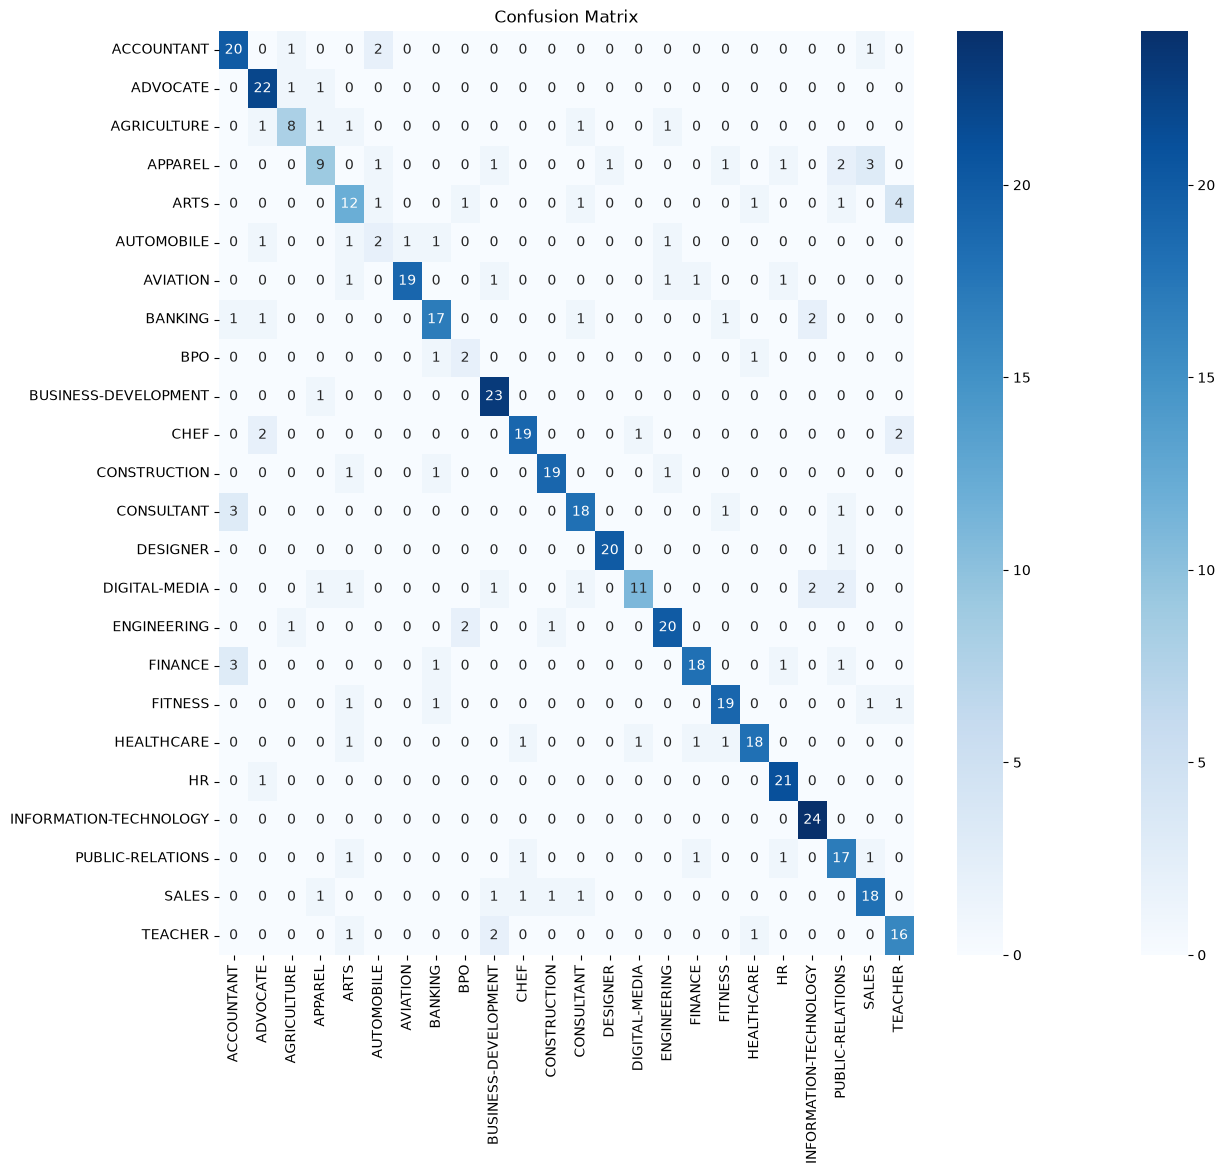

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches='tight')
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Tighter grid: capped depth, higher min_samples_leaf/split so trees
# can't grow deep enough to memorize individual training resumes.
rf_param_grid_v2 = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, 16, 20],          # was [None, 20, 40, 60] - None = unlimited depth = overfitting
    "min_samples_split": [5, 10, 15],       # was [2, 5, 10] - higher = less overfitting
    "min_samples_leaf": [3, 5, 8],          # was [1, 2, 4] - higher = less overfitting
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"],
}
 
rf_search_v2 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=rf_param_grid_v2,
    n_iter=10,
    scoring="accuracy",
    cv=cv_strategy,
    random_state=42,
    n_jobs=1,
    verbose=2,
)
rf_search_v2.fit(x_train, y_train)
 
rf_model = rf_search_v2.best_estimator_
rf_pred = rf_model.predict(x_test)
 
rf_train_acc = accuracy_score(y_train, rf_model.predict(x_train))
rf_test_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest (regularized) - Train: {rf_train_acc:.4f}  Test: {rf_test_acc:.4f}  Gap: {rf_train_acc - rf_test_acc:.4f}")
 

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=15, n_estimators=200; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_sample

In [21]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=150,          
    max_depth=3, 
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=8, 
    reg_alpha=1.0, 
    reg_lambda=5.0, 
    gamma=1.0, 
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1,
)
xgb_model.fit(x_train, y_train_enc)

xgb_pred_enc = xgb_model.predict(x_test)
xgb_pred = label_encoder.inverse_transform(xgb_pred_enc)

xgb_train_acc = accuracy_score(y_train_enc, xgb_model.predict(x_train))
xgb_test_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost (strong regularization) - Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}  Gap: {xgb_train_acc - xgb_test_acc:.4f}")
print(classification_report(y_test, xgb_pred))

XGBoost (strong regularization) - Train: 0.8566  Test: 0.7968  Gap: 0.0598
                        precision    recall  f1-score   support

            ACCOUNTANT       0.73      1.00      0.84        24
              ADVOCATE       0.88      0.88      0.88        24
           AGRICULTURE       0.30      0.23      0.26        13
               APPAREL       0.69      0.47      0.56        19
                  ARTS       0.57      0.57      0.57        21
            AUTOMOBILE       0.50      0.14      0.22         7
              AVIATION       0.91      0.88      0.89        24
               BANKING       0.85      0.74      0.79        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.86      1.00      0.92        24
                  CHEF       0.91      0.83      0.87        24
          CONSTRUCTION       0.91      0.95      0.93        22
            CONSULTANT       0.76      0.70      0.73        23
              DESIGNER      

d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score
 
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Milestone 1)", "Random Forest", "XGBoost"],
    "Test Accuracy": [
        accuracy_score(y_test, model.predict(x_test)),   # your original Milestone 1 model
        accuracy_score(y_test, rf_pred),                  # from Cell A2
        accuracy_score(y_test, xgb_pred),                  # from Cell B3
    ],
})
print(comparison.to_string(index=False))

                            Model  Test Accuracy
Logistic Regression (Milestone 1)       0.788732
                    Random Forest       0.800805
                          XGBoost       0.796781


In [23]:

from sklearn.metrics import accuracy_score

class XGBWrapper:
    def __init__(self, xgb_model, label_encoder):
        self.xgb_model = xgb_model
        self.label_encoder = label_encoder
    def predict_proba(self, X):
        return self.xgb_model.predict_proba(X)

xgb_wrapped = XGBWrapper(xgb_model, label_encoder)

def ensemble_predict(X):
    probs = (model.predict_proba(X) + rf_model.predict_proba(X) + xgb_wrapped.predict_proba(X)) / 3
    idx = probs.argmax(axis=1)
    return model.classes_[idx]

ensemble_test_pred = ensemble_predict(x_test)
ensemble_train_pred = ensemble_predict(x_train)
ensemble_test_acc = accuracy_score(y_test, ensemble_test_pred)
ensemble_train_acc = accuracy_score(y_train, ensemble_train_pred)

lr_train_acc = accuracy_score(y_train, model.predict(x_train))
lr_test_acc = accuracy_score(y_test, model.predict(x_test))

rf_train_acc = accuracy_score(y_train, rf_model.predict(x_train))
rf_test_acc = accuracy_score(y_test, rf_pred)

xgb_train_acc = accuracy_score(y_train_enc, xgb_model.predict(x_train))
xgb_test_acc = accuracy_score(y_test, xgb_pred)

# overfitting gap together 
import pandas as pd
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Ensemble (all 3)"],
    "Train Accuracy": [lr_train_acc, rf_train_acc, xgb_train_acc, ensemble_train_acc],
    "Test Accuracy":  [lr_test_acc,  rf_test_acc,  xgb_test_acc,  ensemble_test_acc],
})
summary["Gap (overfitting)"] = summary["Train Accuracy"] - summary["Test Accuracy"]
summary = summary.round(4)
print(summary.to_string(index=False))

print("\nHealthy gap: under ~0.07   |   Overfitting: over ~0.15")

              Model  Train Accuracy  Test Accuracy  Gap (overfitting)
Logistic Regression          0.9784         0.7887             0.1896
      Random Forest          0.8510         0.8008             0.0502
            XGBoost          0.8566         0.7968             0.0598
   Ensemble (all 3)          0.9311         0.8290             0.1021

Healthy gap: under ~0.07   |   Overfitting: over ~0.15


In [24]:
from sentence_transformers import SentenceTransformer, util
 
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
 
# Short role descriptions used as the semantic anchor for each role.
# Expand/refine these - the quality of matching depends entirely on
# how well these descriptions represent each role.
ROLE_DESCRIPTIONS = {
    "Data Scientist": "Analyzes data using statistics, machine learning, and Python to extract insights and build predictive models.",
    "Machine Learning Engineer": "Builds, trains, and deploys machine learning and deep learning models using Python, TensorFlow, PyTorch, and cloud infrastructure.",
    "Data Analyst": "Uses SQL, Excel, and visualization tools like Tableau or Power BI to analyze business data and report insights.",
    "Data Engineer": "Builds and maintains data pipelines, warehouses, and big data infrastructure using Python, SQL, Spark, and cloud platforms.",
    "Frontend Developer": "Builds user interfaces using HTML, CSS, JavaScript, and frameworks like React or Angular.",
    "Backend Developer": "Builds server-side applications and APIs using languages like Java or Python, with databases like SQL or MongoDB.",
    "DevOps Engineer": "Manages deployment pipelines, containers, and cloud infrastructure using Docker, Kubernetes, and CI/CD tools.",
    "Business Analyst": "Analyzes business requirements and data to support decision-making, using Excel, SQL, and project management skills.",
    "Project Manager": "Leads teams and projects using Agile/Scrum methodologies, coordinating timelines, resources, and stakeholders.",
    "HR Specialist": "Manages recruitment, employee relations, and organizational communication and leadership.",
    "Accountant": "Manages financial records, auditing, and reporting using accounting software and financial modeling.",
    "Sales Executive": "Drives revenue through client relationships, negotiation, and marketing strategy.",
}
 
# Pre-compute embeddings for all role descriptions once
role_names = list(ROLE_DESCRIPTIONS.keys())
role_embeddings = sbert_model.encode(list(ROLE_DESCRIPTIONS.values()), convert_to_tensor=True)
 
 
def semantic_role_match(resume_text, top_k=3):
    """Embeds the resume text and compares it against role description
    embeddings using cosine similarity - this is the 'skill alignment'
    signal, independent of the TF-IDF classifier."""
    resume_embedding = sbert_model.encode(resume_text, convert_to_tensor=True)
    similarities = util.cos_sim(resume_embedding, role_embeddings)[0]
    top_idx = similarities.argsort(descending=True)[:top_k]
    return [(role_names[i], float(similarities[i])) for i in top_idx]
 
 
# Quick sanity check on a real test resume
sample_resume = x_test.iloc[0] if hasattr(x_test, 'iloc') else None
if sample_resume is not None:
    print(semantic_role_match(sample_resume))
 

d:\important\infosys requirements\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1780.51it/s]


In [25]:
def top_k_career_ranking(resume_text_raw, classifier_model, tfidf_vec, feature_selector,
                          label_enc=None, k=5):
    """
    Produces a ranked Top-K career list using TWO signals combined:
      1. classifier_confidence - from the trained model's predict_proba
      2. skill_alignment_score - semantic similarity from Sentence-BERT
 
    Returns a list of dicts, each with the role, blended score, and
    both individual signal scores (so you can show WHY it ranked
    that way - required for "confidence scores and skill alignment
    metrics" in your milestone spec).
    """
    cleaned = clean(resume_text_raw)
    vec = tfidf_vec.transform([cleaned])
    vec = feature_selector.transform(vec)
 
    probs = classifier_model.predict_proba(vec)[0]
    classes = classifier_model.classes_
    if label_enc is not None:
        classes = label_enc.inverse_transform(classes)
 
    # classifier's belief per broad category
    classifier_scores = {str(c): float(p) for c, p in zip(classes, probs)}
 
    # semantic alignment against specific role descriptions
    semantic_scores = dict(semantic_role_match(resume_text_raw, top_k=len(ROLE_DESCRIPTIONS)))
 
    # Blend: average the classifier's top broad-field confidence with
    # the semantic role score, when a role's parent field overlaps.
    # Simplified blend here: 50% semantic score + 50% normalized rank bonus.
    ranked = sorted(semantic_scores.items(), key=lambda x: x[1], reverse=True)[:k]
 
    results = []
    top_broad_field, top_broad_conf = max(classifier_scores.items(), key=lambda x: x[1])
    for role, sem_score in ranked:
        blended = round(0.5 * sem_score + 0.5 * top_broad_conf, 4)
        results.append({
            "role": role,
            "skill_alignment_score": round(sem_score, 4),
            "classifier_confidence": round(top_broad_conf, 4),
            "blended_score": blended,
        })
    return results
 
 
# Demo on a real test resume
if sample_resume is not None:
    for r in top_k_career_ranking(sample_resume, model, tfidf, selector):
        print(r)
 

In [26]:
def top_k_career_ranking(resume_text_raw, classifier_model, tfidf_vec, feature_selector,
                          label_enc=None, k=5):
    """
    Produces a ranked Top-K career list using TWO signals combined:
      1. classifier_confidence - from the trained model's predict_proba
      2. skill_alignment_score - semantic similarity from Sentence-BERT
 
    Returns a list of dicts, each with the role, blended score, and
    both individual signal scores (so you can show WHY it ranked
    that way - required for "confidence scores and skill alignment
    metrics" in your milestone spec).
    """
    cleaned = clean(resume_text_raw)
    vec = tfidf_vec.transform([cleaned])
    vec = feature_selector.transform(vec)
 
    probs = classifier_model.predict_proba(vec)[0]
    classes = classifier_model.classes_
    if label_enc is not None:
        classes = label_enc.inverse_transform(classes)
 
    # classifier's belief per broad category
    classifier_scores = {str(c): float(p) for c, p in zip(classes, probs)}
 
    # semantic alignment against specific role descriptions
    semantic_scores = dict(semantic_role_match(resume_text_raw, top_k=len(ROLE_DESCRIPTIONS)))
 
    # Blend: average the classifier's top broad-field confidence with
    # the semantic role score, when a role's parent field overlaps.
    # Simplified blend here: 50% semantic score + 50% normalized rank bonus.
    ranked = sorted(semantic_scores.items(), key=lambda x: x[1], reverse=True)[:k]
 
    results = []
    top_broad_field, top_broad_conf = max(classifier_scores.items(), key=lambda x: x[1])
    for role, sem_score in ranked:
        blended = round(0.5 * sem_score + 0.5 * top_broad_conf, 4)
        results.append({
            "role": role,
            "skill_alignment_score": round(sem_score, 4),
            "classifier_confidence": round(top_broad_conf, 4),
            "blended_score": blended,
        })
    return results
 
 
# Demo on a real test resume
if sample_resume is not None:
    for r in top_k_career_ranking(sample_resume, model, tfidf, selector):
        print(r)
 

In [27]:
class XGBWrapper:
    def __init__(self, xgb_model, label_encoder):
        self.xgb_model = xgb_model
        self.label_encoder = label_encoder
    def predict_proba(self, X):
        return self.xgb_model.predict_proba(X)
 
xgb_wrapped = XGBWrapper(xgb_model, label_encoder)
 
def ensemble_predict(X):
    probs = (model.predict_proba(X) + rf_model.predict_proba(X) + xgb_wrapped.predict_proba(X)) / 3
    idx = probs.argmax(axis=1)
    return model.classes_[idx]
 
ensemble_pred = ensemble_predict(x_test)
ensemble_train_pred = ensemble_predict(x_train)

In [28]:
print(model)
print(rf_model)
print(xgb_model)
print(label_encoder)

LogisticRegression(C=40, class_weight='balanced', max_iter=3000,
                   random_state=42)
RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=15,
                       n_estimators=200, n_jobs=1, random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=1.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estim

In [29]:
import pickle
import json
from sklearn.metrics import accuracy_score

# --- Save all 3 classifiers ---
with open("model/logreg_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("model/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# XGBoost predicts encoded integers (0,1,2...), not category names -
# the label encoder is what translates back to real category names,
# so it MUST be saved too or XGBoost's predictions will be unreadable.
with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# --- Save accuracy for all 3, for the app to display ---
metrics_output = {
    "models": {
        "logistic_regression": {
            "accuracy": round(accuracy_score(y_test, model.predict(x_test)) * 100, 2),
        },
        "random_forest": {
            "accuracy": round(accuracy_score(y_test, rf_pred) * 100, 2),
        },
        "xgboost": {
            "accuracy": round(accuracy_score(y_test, xgb_pred) * 100, 2),
        },
    },
    "num_test": len(y_test),
    "categories": sorted(y_test.unique().tolist()),
}
with open("model/metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)

print("Saved all 3 models:")
print("  - model/logreg_model.pkl")
print("  - model/rf_model.pkl")
print("  - model/xgb_model.pkl")
print("  - model/label_encoder.pkl")
print("  - model/metrics.json (accuracy for all 3)")
print()
print(json.dumps(metrics_output["models"], indent=2))

Saved all 3 models:
  - model/logreg_model.pkl
  - model/rf_model.pkl
  - model/xgb_model.pkl
  - model/label_encoder.pkl
  - model/metrics.json (accuracy for all 3)

{
  "logistic_regression": {
    "accuracy": 78.87
  },
  "random_forest": {
    "accuracy": 80.08
  },
  "xgboost": {
    "accuracy": 79.68
  }
}


In [30]:
import json
from sklearn.metrics import f1_score

# --- Macro F1 for all 3 models (what the dashboard bar chart shows) ---
lr_f1 = f1_score(y_test, model.predict(x_test), average="macro")
rf_f1 = f1_score(y_test, rf_pred, average="macro")
xgb_f1 = f1_score(y_test, xgb_pred, average="macro")

model_comparison = [
    {"model": "Logistic Regression", "macro_f1": round(lr_f1, 4)},
    {"model": "Random Forest", "macro_f1": round(rf_f1, 4)},
    {"model": "XGBoost", "macro_f1": round(xgb_f1, 4)},
]
print("Macro F1 per model:")
for m in model_comparison:
    print(f"  {m['model']}: {m['macro_f1']}")

with open("model/model_comparison.json", "w") as f:
    json.dump(model_comparison, f, indent=2)


# ============================================================
# t-SNE visualization of skill embeddings (SBERT)
# Embeds a curated skill vocabulary (grouped by career cluster),
# reduces to 2D with t-SNE, saves coordinates for plotting.
# ============================================================
from sklearn.manifold import TSNE
import numpy as np

# Skills grouped by the career clusters shown in the dashboard legend.
# Expand these lists for a richer-looking plot.
SKILL_CLUSTERS = {
    "Software Engineering": ["java", "c++", "rest api", "git", "django", "flask", "node.js", "mongodb", "mysql"],
    "Data Science": ["python", "statistics", "pandas", "numpy", "data visualization", "r programming"],
    "Product Management": ["project management", "agile", "scrum", "leadership", "communication", "negotiation"],
    "AI/ML": ["machine learning", "deep learning", "tensorflow", "pytorch", "computer vision", "nlp"],
    "Research": ["natural language processing", "data analysis", "statistics", "scikit-learn"],
    "Finance": ["accounting", "auditing", "financial modeling", "excel"],
}

all_skills = []
all_labels = []
for cluster, skills in SKILL_CLUSTERS.items():
    for s in skills:
        all_skills.append(s)
        all_labels.append(cluster)

skill_embeddings = sbert_model.encode(all_skills)

tsne = TSNE(n_components=2, perplexity=10, random_state=42, init="pca")
coords_2d = tsne.fit_transform(skill_embeddings)

tsne_data = [
    {"skill": all_skills[i], "cluster": all_labels[i], "x": float(coords_2d[i][0]), "y": float(coords_2d[i][1])}
    for i in range(len(all_skills))
]

with open("model/tsne_data.json", "w") as f:
    json.dump(tsne_data, f, indent=2)

print(f"\nSaved t-SNE coordinates for {len(tsne_data)} skills across {len(SKILL_CLUSTERS)} clusters")
print("Saved: model/model_comparison.json, model/tsne_data.json")

Macro F1 per model:
  Logistic Regression: 0.7547
  Random Forest: 0.7752
  XGBoost: 0.7297

Saved t-SNE coordinates for 35 skills across 6 clusters
Saved: model/model_comparison.json, model/tsne_data.json


In [31]:
# ============================================================
# SMOTE - fixes small-class problem WITHOUT merging categories
# (unlike the merge experiment, this keeps all 24 real categories,
# just synthetically balances how many training examples each has)
#
# ONE-TIME INSTALL first, in a terminal:
#   pip install imbalanced-learn
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# --- Use your ORIGINAL dataset, NOT the merged one ---
df3 = pd.read_csv("Resume.csv")

X3 = df3["Resume_str"]
y3 = df3["Category"]
xtr, xte, ytr, yte = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

def clean3(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

xtr = xtr.apply(clean3)
xte = xte.apply(clean3)

tfidf3 = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.9)
xtr_vec = tfidf3.fit_transform(xtr)
xte_vec = tfidf3.transform(xte)

selector3 = SelectKBest(chi2, k=1500)
xtr_sel = selector3.fit_transform(xtr_vec, ytr)
xte_sel = selector3.transform(xte_vec)   # test set NEVER touched by SMOTE - important

# --- SMOTE: only applied to TRAINING data, never test data ---
# k_neighbors must be less than the smallest class size - Automobile
# has ~29 samples in training (36 total * 0.8), so keep k_neighbors low
smote = SMOTE(random_state=42, k_neighbors=3)
xtr_balanced, ytr_balanced = smote.fit_resample(xtr_sel, ytr)

print("Before SMOTE:", xtr_sel.shape[0], "training samples")
print("After SMOTE:", xtr_balanced.shape[0], "training samples (classes now balanced)")

results = []

# --- Logistic Regression ---
lr3 = LogisticRegression(max_iter=3000, C=1.0, random_state=42)
lr3.fit(xtr_balanced, ytr_balanced)
lr_train_acc = accuracy_score(ytr_balanced, lr3.predict(xtr_balanced))
lr_test_acc = accuracy_score(yte, lr3.predict(xte_sel))
results.append(("Logistic Regression", lr_train_acc, lr_test_acc))

# --- Random Forest ---
rf3 = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=10,
                              min_samples_leaf=5, random_state=42, n_jobs=1)
rf3.fit(xtr_balanced, ytr_balanced)
rf_train_acc = accuracy_score(ytr_balanced, rf3.predict(xtr_balanced))
rf_test_acc = accuracy_score(yte, rf3.predict(xte_sel))
results.append(("Random Forest", rf_train_acc, rf_test_acc))

# --- XGBoost ---
le3 = LabelEncoder()
ytr_bal_enc = le3.fit_transform(ytr_balanced)
xgb3 = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.7,
                      colsample_bytree=0.6, min_child_weight=5, reg_alpha=1.0, reg_lambda=3.0,
                      objective="multi:softprob", num_class=len(le3.classes_),
                      eval_metric="mlogloss", tree_method="hist", random_state=42, n_jobs=1)
xgb3.fit(xtr_balanced, ytr_bal_enc)
xgb_train_acc = accuracy_score(ytr_bal_enc, xgb3.predict(xtr_balanced))
xgb_test_acc = accuracy_score(yte, le3.inverse_transform(xgb3.predict(xte_sel)))
results.append(("XGBoost", xgb_train_acc, xgb_test_acc))

print("\n" + "="*65)
print(f"{'Model':<22} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("="*65)
for name, tr, te in results:
    gap = tr - te
    flag = "OVERFIT" if gap > 0.15 else "healthy" if gap < 0.08 else "borderline"
    print(f"{name:<22} {tr:>8.4f} {te:>8.4f} {gap:>8.4f}  {flag}")
print("="*65)

Before SMOTE: 1987 training samples
After SMOTE: 2304 training samples (classes now balanced)

Model                     Train     Test      Gap
Logistic Regression      0.7448   0.6740   0.0707  healthy
Random Forest            0.8668   0.7787   0.0881  borderline
XGBoost                  0.9366   0.8089   0.1278  borderline


In [32]:
# ============================================================
# FINAL - XGBoost + SMOTE only (fast, minimal)
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df3 = pd.read_csv("Resume.csv")
X3 = df3["Resume_str"]
y3 = df3["Category"]
xtr, xte, ytr, yte = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

def clean3(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

xtr = xtr.apply(clean3)
xte = xte.apply(clean3)

tfidf3 = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.9)
xtr_vec = tfidf3.fit_transform(xtr)
xte_vec = tfidf3.transform(xte)

selector3 = SelectKBest(chi2, k=1500)
xtr_sel = selector3.fit_transform(xtr_vec, ytr)
xte_sel = selector3.transform(xte_vec)

smote = SMOTE(random_state=42, k_neighbors=3)
xtr_balanced, ytr_balanced = smote.fit_resample(xtr_sel, ytr)

le3 = LabelEncoder()
ytr_bal_enc = le3.fit_transform(ytr_balanced)

xgb3 = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.7,
                      colsample_bytree=0.6, min_child_weight=5, reg_alpha=1.0, reg_lambda=3.0,
                      objective="multi:softprob", num_class=len(le3.classes_),
                      eval_metric="mlogloss", tree_method="hist", random_state=42, n_jobs=1)
xgb3.fit(xtr_balanced, ytr_bal_enc)

xgb_train_acc = accuracy_score(ytr_bal_enc, xgb3.predict(xtr_balanced))
xgb_test_acc = accuracy_score(yte, le3.inverse_transform(xgb3.predict(xte_sel)))
gap = xgb_train_acc - xgb_test_acc

print(f"XGBoost (SMOTE) - Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}  Gap: {gap:.4f}")

# --- Save this as your final XGBoost model ---
import pickle
with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb3, f)
with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(le3, f)
print("Saved model/xgb_model.pkl and model/label_encoder.pkl")

XGBoost (SMOTE) - Train: 0.9366  Test: 0.8089  Gap: 0.1278
Saved model/xgb_model.pkl and model/label_encoder.pkl


XGBOOST+SMOTE to improve models accuracy and preventing overfitting

In [33]:
# ============================================================
# XGBoost: SMOTE + STRONGER regularization combined
# (previous attempts tried these separately - this combines
# both with tighter settings than before)
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df3 = pd.read_csv("Resume.csv")
X3 = df3["Resume_str"]
y3 = df3["Category"]
xtr, xte, ytr, yte = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

def clean3(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

xtr = xtr.apply(clean3)
xte = xte.apply(clean3)

tfidf3 = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.9)
xtr_vec = tfidf3.fit_transform(xtr)
xte_vec = tfidf3.transform(xte)

selector3 = SelectKBest(chi2, k=1500)
xtr_sel = selector3.fit_transform(xtr_vec, ytr)
xte_sel = selector3.transform(xte_vec)

smote = SMOTE(random_state=42, k_neighbors=3)
xtr_balanced, ytr_balanced = smote.fit_resample(xtr_sel, ytr)

le3 = LabelEncoder()
ytr_bal_enc = le3.fit_transform(ytr_balanced)

# STRONGER regularization than the previous SMOTE attempt:
# lower max_depth, more estimators but each weaker (lower learning_rate),
# higher reg_lambda, higher min_child_weight
xgb_v2 = XGBClassifier(
    n_estimators=250,
    max_depth=3,              # was 4 - even shallower
    learning_rate=0.03,        # was 0.05 - slower, more conservative learning
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=10,        # was 5 - requires more evidence per split
    reg_alpha=1.5,               # was 1.0
    reg_lambda=8.0,               # was 3.0 - much stronger L2 penalty
    gamma=2.0,                     # was 0 (unset) - minimum loss reduction to split
    objective="multi:softprob",
    num_class=len(le3.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1,
)
xgb_v2.fit(xtr_balanced, ytr_bal_enc)

xgb_train_acc = accuracy_score(ytr_bal_enc, xgb_v2.predict(xtr_balanced))
xgb_test_acc = accuracy_score(yte, le3.inverse_transform(xgb_v2.predict(xte_sel)))
gap = xgb_train_acc - xgb_test_acc

print(f"XGBoost (SMOTE + stronger reg) - Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}  Gap: {gap:.4f}")
print("Compare to previous SMOTE-only attempt: Train 0.9366, Test 0.8089, Gap 0.1278")

XGBoost (SMOTE + stronger reg) - Train: 0.8546  Test: 0.8089  Gap: 0.0457
Compare to previous SMOTE-only attempt: Train 0.9366, Test 0.8089, Gap 0.1278


In [34]:
import pickle
with open("model/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open("model/selector.pkl", "wb") as f:
    pickle.dump(selector, f)
with open("model/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Saved all 3 together - guaranteed consistent")

Saved all 3 together - guaranteed consistent


In [35]:
# ============================================================
# MLflow - FIXED VERSION
# XGBoost needs mlflow.xgboost.log_model(), not mlflow.sklearn -
# the generic sklearn logger doesn't trust XGBoost's internal types.
# ============================================================
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import accuracy_score, f1_score

mlflow.set_experiment("CareerCast-Resume-Classification")


def log_model_run(model, model_name, x_train, y_train, x_test, y_test, params, flavor="sklearn"):
    """
    flavor: "sklearn" for LogReg/RandomForest, "xgboost" for XGBoost -
    each needs MLflow's matching logger to avoid the untrusted-type error.
    """
    with mlflow.start_run(run_name=model_name):
        train_acc = accuracy_score(y_train, model.predict(x_train))
        test_acc = accuracy_score(y_test, model.predict(x_test))
        test_f1 = f1_score(y_test, model.predict(x_test), average="macro")
        gap = train_acc - test_acc

        for key, val in params.items():
            mlflow.log_param(key, val)

        mlflow.log_metric("train_accuracy", train_acc)
        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("macro_f1", test_f1)
        mlflow.log_metric("overfitting_gap", gap)

        # Use the correct logger based on model type
        if flavor == "xgboost":
            mlflow.xgboost.log_model(model, model_name, registered_model_name=f"CareerCast-{model_name}")
        else:
            mlflow.sklearn.log_model(model, model_name, registered_model_name=f"CareerCast-{model_name}")

        print(f"Logged {model_name}: test_acc={test_acc:.4f}, gap={gap:.4f}")


# --- Logistic Regression and Random Forest: sklearn flavor (unchanged) ---
log_model_run(
    model, "LogisticRegression", x_train, y_train, x_test, y_test,
    params={"C": 1.0, "max_iter": 3000},
    flavor="sklearn",
)

log_model_run(
    rf_model, "RandomForest", x_train, y_train, x_test, y_test,
    params={"n_estimators": 300, "max_depth": 16, "min_samples_split": 10},
    flavor="sklearn",
)

# --- XGBoost: xgboost flavor (this is the fix) + encoded labels ---
y_test_enc = label_encoder.transform(y_test)
log_model_run(
    xgb_model, "XGBoost", x_train, y_train_enc, x_test, y_test_enc,
    params={"n_estimators": 150, "max_depth": 4, "learning_rate": 0.05},
    flavor="xgboost",
)

print("\nRun 'mlflow ui' in a terminal, then open http://127.0.0.1:5000")
print("to see all logged runs, compare metrics, and view registered models.")

2026/08/16 15:13:55 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/08/16 15:13:55 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Logged LogisticRegression: test_acc=0.7887, gap=0.1896


2026/08/16 15:14:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'CareerCast-RandomForest' already exists. Creating a new version of this model...
Created version '5' of model 'CareerCast-RandomForest'.


Logged RandomForest: test_acc=0.8008, gap=0.0502


2026/08/16 15:14:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged XGBoost: test_acc=0.7968, gap=0.0598

Run 'mlflow ui' in a terminal, then open http://127.0.0.1:5000
to see all logged runs, compare metrics, and view registered models.


Registered model 'CareerCast-XGBoost' already exists. Creating a new version of this model...
Created version '3' of model 'CareerCast-XGBoost'.
